[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/No-Country-simulation/G9-BR-Team-19/blob/main/Data%20Science/TechMind_Oficial.ipynb)

# <font color="#0a8f08">**G9-BR-Team-19**</font>

# <font color='red' style='font-size: 30px;'>1.2 Extração do Arquivo Tratado</font>
<hr style='border: 2px solid red;'>

In [1]:
import re
import string
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_colwidth', 120)

In [2]:
SUBTOPICS = {
    "Backend": [
        "APIs REST", "Spring Boot", "Node.js e Express", "autenticação JWT",
        "arquitetura de microsserviços", "bancos de dados relacionais",
        "ORM e Hibernate", "mensageria com RabbitMQ", "GraphQL",
        "cache com Redis", "testes unitários em Java", "Clean Architecture",
        "versionamento de APIs", "tratamento de exceções em APIs"
    ],
    "Frontend": [
        "React.js", "componentes reutilizáveis", "gerenciamento de estado com Redux",
        "Vue.js", "CSS Grid e Flexbox", "acessibilidade web",
        "TypeScript no front-end", "performance de renderização",
        "Webpack e bundling", "design responsivo", "hooks do React", "Next.js",
        "consumo de APIs no front-end", "testes de componentes com Jest"
    ],
    "Data Science": [
        "análise exploratória de dados", "machine learning supervisionado",
        "processamento de linguagem natural", "pandas e manipulação de dados",
        "modelos de classificação", "engenharia de features",
        "visualização de dados", "redes neurais", "regressão logística",
        "clustering e agrupamento", "métricas de avaliação de modelos",
        "scikit-learn", "séries temporais", "validação cruzada"
    ],
    "DevOps": [
        "integração contínua", "pipelines de CI/CD", "containers com Docker",
        "orquestração com Kubernetes", "infraestrutura como código",
        "monitoramento e observabilidade", "Terraform", "automação de deploy",
        "Jenkins", "GitOps", "escalabilidade de infraestrutura",
        "logs centralizados", "gestão de segredos", "blue-green deployment"
    ],
    "Mobile": [
        "desenvolvimento com Flutter", "aplicativos Android nativos",
        "Swift e iOS", "React Native", "UI mobile responsiva",
        "notificações push", "armazenamento local em apps",
        "ciclo de vida de atividades Android", "publicação na Play Store",
        "consumo de APIs REST em apps móveis", "performance de aplicativos móveis",
        "Kotlin", "testes de interface em apps", "modo offline em aplicativos"
    ],
    "Cloud": [
        "computação em nuvem", "armazenamento em nuvem (Object Storage)",
        "OCI Compute", "serverless e Functions", "escalabilidade automática",
        "redes virtuais na nuvem", "segurança em ambientes cloud",
        "migração para a nuvem", "provedores AWS e Azure",
        "custos e otimização em cloud", "bancos de dados gerenciados na nuvem",
        "alta disponibilidade", "balanceamento de carga na nuvem",
        "backup e recuperação de desastres"
    ],
}

TITLE_TEMPLATES = [
    "Introdução a {t1}",
    "Como funciona {t1}",
    "Boas práticas em {t1}",
    "Guia completo sobre {t1}",
    "Entendendo {t1} na prática",
    "{t1}: conceitos essenciais",
    "Um panorama sobre {t1}",
    "Primeiros passos com {t1}",
]

TEXT_TEMPLATES = [
    "Este conteúdo apresenta os principais conceitos sobre {t1}. São abordados temas "
    "como {t2} e {t3}, além de exemplos práticos de aplicação no dia a dia de "
    "desenvolvimento. O objetivo é fornecer uma base sólida para quem deseja "
    "aprofundar conhecimentos em {t1}.",

    "Neste material, discutimos {t1} com foco em aplicações reais. Também são "
    "explorados aspectos relacionados a {t2}, com dicas de boas práticas e "
    "armadilhas comuns. Ao final, o leitor terá uma visão prática sobre {t3}.",

    "Um estudo detalhado sobre {t1}, cobrindo desde os fundamentos até tópicos mais "
    "avançados como {t2}. O texto também relaciona {t1} com {t3}, mostrando como "
    "esses conceitos se conectam em projetos do mundo real.",

    "Esta documentação técnica explica {t1} passo a passo, com exemplos de código "
    "e cenários de uso. Também é discutida a relação entre {t2} e {t3}, "
    "reforçando quando cada abordagem deve ser utilizada.",

    "Notas de estudo sobre {t1}: principais definições, vantagens e desvantagens. "
    "O conteúdo também compara {t1} com {t2} e apresenta um exemplo prático "
    "envolvendo {t3} para fixar o aprendizado.",

    "Tutorial prático que ensina {t1} do zero. Ao longo do texto, também são "
    "apresentados conceitos de {t2}, e ao final é proposto um exercício "
    "envolvendo {t3} para consolidar o conteúdo.",
]

N_PER_CATEGORY = 60

RESUMO_TEMPLATES = [
    "Resumo: visão geral sobre {t1}, com destaque para {t2} e {t3}.",
    "Resumo: principais conceitos de {t1}, relacionando-os com {t2} e {t3}.",
    "Resumo: guia rápido sobre {t1}, abordando também {t2} e {t3}.",
    "Resumo: panorama prático de {t1}, com menções a {t2} e {t3}.",
]

def generate_dataset():
    rows = []
    for categoria, subtopics in SUBTOPICS.items():
        for _ in range(N_PER_CATEGORY):
            t1, t2, t3 = random.sample(subtopics, 3)
            title = random.choice(TITLE_TEMPLATES).format(t1=t1)
            text = random.choice(TEXT_TEMPLATES).format(t1=t1, t2=t2, t3=t3)
            resumo = random.choice(RESUMO_TEMPLATES).format(t1=t1, t2=t2, t3=t3)
            rows.append({
                "titulo": title,
                "texto": text,
                "categoria": categoria,
                "tag1": t1,
                "tag2": t2,
                "tag3": t3,
                "resumo": resumo,
            })
    df = pd.DataFrame(rows)
    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    return df

df = generate_dataset()
df.to_csv("techmind_dataset.csv", index=False)
print(f"Base gerada com {len(df)} registros ({df['categoria'].nunique()} categorias).")
df.head(10)

Base gerada com 360 registros (6 categorias).


,titulo,texto,categoria,tag1,tag2,tag3,resumo
0,Guia completo sobre orquestração com Kubernetes,Este conteúdo apresenta os principais conceitos sobre orquestração com Kubernetes. São abordados temas como containe...,DevOps,orquestração com Kubernetes,containers com Docker,GitOps,"Resumo: principais conceitos de orquestração com Kubernetes, relacionando-os com containers com Docker e GitOps."
1,Um panorama sobre GraphQL,"Neste material, discutimos GraphQL com foco em aplicações reais. Também são explorados aspectos relacionados a mensa...",Backend,GraphQL,mensageria com RabbitMQ,Node.js e Express,"Resumo: guia rápido sobre GraphQL, abordando também mensageria com RabbitMQ e Node.js e Express."
2,consumo de APIs REST em apps móveis: conceitos essenciais,"Um estudo detalhado sobre consumo de APIs REST em apps móveis, cobrindo desde os fundamentos até tópicos mais avança...",Mobile,consumo de APIs REST em apps móveis,performance de aplicativos móveis,Swift e iOS,"Resumo: panorama prático de consumo de APIs REST em apps móveis, com menções a performance de aplicativos móveis e S..."
3,Um panorama sobre computação em nuvem,"Notas de estudo sobre computação em nuvem: principais definições, vantagens e desvantagens. O conteúdo também compar...",Cloud,computação em nuvem,segurança em ambientes cloud,backup e recuperação de desastres,"Resumo: guia rápido sobre computação em nuvem, abordando também segurança em ambientes cloud e backup e recuperação ..."
4,Primeiros passos com versionamento de APIs,"Notas de estudo sobre versionamento de APIs: principais definições, vantagens e desvantagens. O conteúdo também comp...",Backend,versionamento de APIs,Spring Boot,APIs REST,"Resumo: visão geral sobre versionamento de APIs, com destaque para Spring Boot e APIs REST."
5,Boas práticas em modo offline em aplicativos,"Esta documentação técnica explica modo offline em aplicativos passo a passo, com exemplos de código e cenários de us...",Mobile,modo offline em aplicativos,performance de aplicativos móveis,notificações push,"Resumo: visão geral sobre modo offline em aplicativos, com destaque para performance de aplicativos móveis e notific..."
6,Guia completo sobre tratamento de exceções em APIs,Este conteúdo apresenta os principais conceitos sobre tratamento de exceções em APIs. São abordados temas como versi...,Backend,tratamento de exceções em APIs,versionamento de APIs,APIs REST,"Resumo: guia rápido sobre tratamento de exceções em APIs, abordando também versionamento de APIs e APIs REST."
7,Entendendo Spring Boot na prática,"Neste material, discutimos Spring Boot com foco em aplicações reais. Também são explorados aspectos relacionados a G...",Backend,Spring Boot,GraphQL,autenticação JWT,"Resumo: guia rápido sobre Spring Boot, abordando também GraphQL e autenticação JWT."
8,Entendendo desenvolvimento com Flutter na prática,"Um estudo detalhado sobre desenvolvimento com Flutter, cobrindo desde os fundamentos até tópicos mais avançados como...",Mobile,desenvolvimento com Flutter,Swift e iOS,UI mobile responsiva,"Resumo: guia rápido sobre desenvolvimento com Flutter, abordando também Swift e iOS e UI mobile responsiva."
9,Entendendo scikit-learn na prática,"Notas de estudo sobre scikit-learn: principais definições, vantagens e desvantagens. O conteúdo também compara sciki...",Data Science,scikit-learn,regressão logística,métricas de avaliação de modelos,"Resumo: panorama prático de scikit-learn, com menções a regressão logística e métricas de avaliação de modelos."


In [3]:
# John Lenon Nogueria
# ==========================================
# 1. Lista de stopwords em português (customizada)
# ==========================================
STOPWORDS_PT = set("""
a ao aos aquela aquelas aquele aqueles aquilo as até com como da das de dela
delas dele deles depois do dos e ela elas ele eles em entre era eram essa
essas esse esses esta estas este estes estou eu foi fomos for foram fosse
fossem fui há isso isto já lhe lhes mais mas me mesmo meu meus minha minhas
muito na nas nem no nos nossa nossas nosso nossos num numa não nós o os
ou para pela pelas pelo pelos por qual quando que quem se seu seus somos
sou sua suas são também te tem tem também teu teus tu tua tuas um uma
você vocês vos à às pode podem ser sendo sido têm foi ser será serão
""".split())

# ==========================================
# 2. Função de limpeza de texto
# ==========================================
def limpar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ASCII", "ignore").decode("utf-8")
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    palavras = [p for p in texto.split() if p not in STOPWORDS_PT and len(p) > 2]
    return " ".join(palavras)

# ==========================================
# 3. Criei a coluna de texto combinado (titulo + texto)
#    -> dá mais contexto para o modelo do que só o corpo
# ==========================================
df["texto_completo"] = df["titulo"] + " " + df["texto"]
df["texto_limpo"] = df["texto_completo"].apply(limpar_texto)

print(df[["titulo", "texto_limpo"]].head(3))

# ==========================================
# 4. Separação features (X) e target (y)
# ==========================================
X = df["texto_limpo"]
y = df["categoria"]

# ==========================================
# 5. Split treino/teste (estratifiquei para manter proporção das categorias)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Treino: {len(X_train)} registros | Teste: {len(X_test)} registros")
print(y_train.value_counts())

# ==========================================
# 6. Vetorização TF-IDF
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),   # Usei unigramas + bigramas, ajudam a capturar termos técnicos compostos
    min_df=2,
    max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Shape do treino vetorizado: {X_train_tfidf.shape}")
print(f"Shape do teste vetorizado: {X_test_tfidf.shape}")

                                                      titulo  \
0            Guia completo sobre orquestração com Kubernetes   
1                                  Um panorama sobre GraphQL   
2  consumo de APIs REST em apps móveis: conceitos essenciais   

                                                                                                               texto_limpo  
0  guia completo sobre orquestracao kubernetes conteudo apresenta principais conceitos sobre orquestracao kubernetes sa...  
1  panorama sobre graphql neste material discutimos graphql foco aplicacoes reais tambem sao explorados aspectos relaci...  
2  consumo apis rest apps moveis conceitos essenciais estudo detalhado sobre consumo apis rest apps moveis cobrindo des...  
Treino: 288 registros | Teste: 72 registros
categoria
Frontend        48
Backend         48
Data Science    48
DevOps          48
Mobile          48
Cloud           48
Name: count, dtype: int64
Shape do treino vetorizado: (288, 908)
Shape do t


Modelo: Logistic Regression
Acurácia: 1.0000
              precision    recall  f1-score   support

     Backend       1.00      1.00      1.00        12
       Cloud       1.00      1.00      1.00        12
Data Science       1.00      1.00      1.00        12
      DevOps       1.00      1.00      1.00        12
    Frontend       1.00      1.00      1.00        12
      Mobile       1.00      1.00      1.00        12

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72


Modelo: Naive Bayes
Acurácia: 0.9722
              precision    recall  f1-score   support

     Backend       1.00      0.83      0.91        12
       Cloud       1.00      1.00      1.00        12
Data Science       1.00      1.00      1.00        12
      DevOps       1.00      1.00      1.00        12
    Frontend       0.86      1.00      0.92        12
      Mobile       1.00      1.00      1.00     

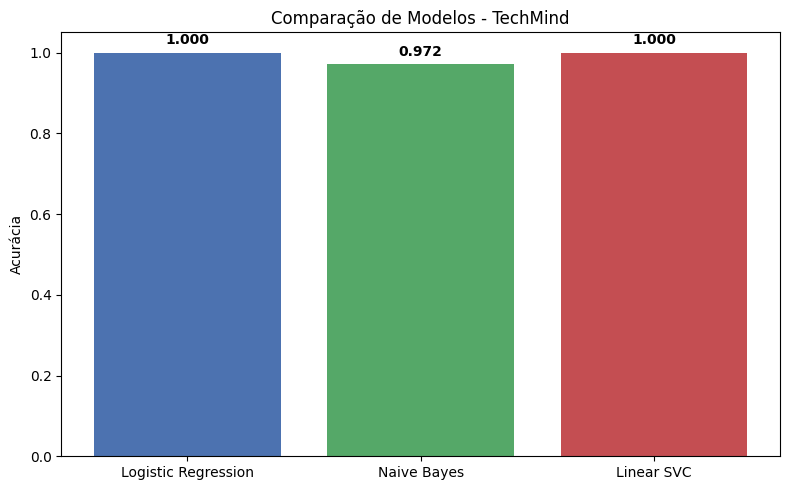


Melhor modelo: Logistic Regression (acurácia: 1.0000)


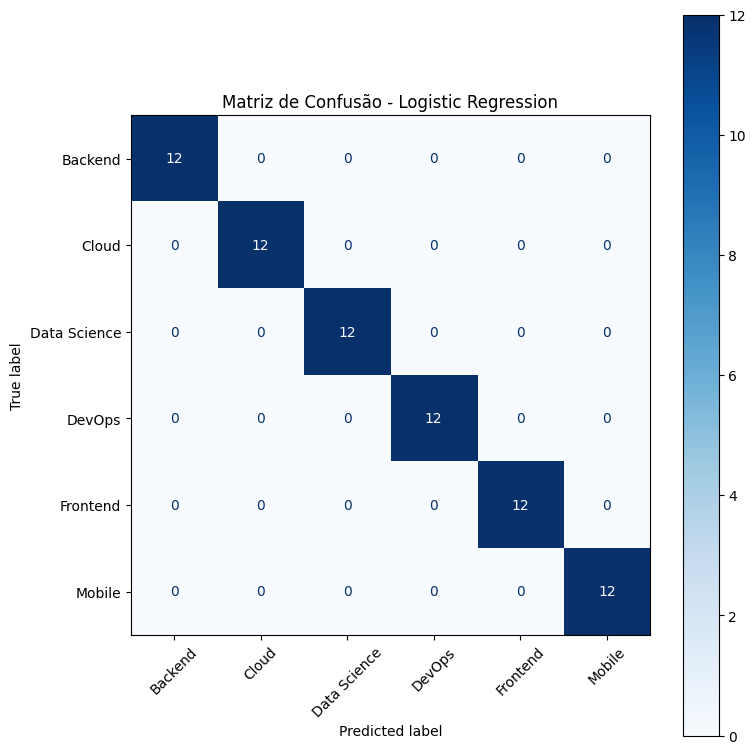


Modelo e vectorizer salvos com sucesso!


In [4]:
# John Lenon Nogueira
# ==========================================
# 1. Treinar múltiplos modelos
# ==========================================
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(random_state=RANDOM_SEED, max_iter=5000),
}

resultados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = {
        "modelo": modelo,
        "y_pred": y_pred,
        "acuracia": acc
    }
    print(f"\n{'='*50}")
    print(f"Modelo: {nome}")
    print(f"Acurácia: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))

# ==========================================
# 2. Comparação visual das acurácias
# ==========================================
nomes = list(resultados.keys())
acuracias = [resultados[n]["acuracia"] for n in nomes]

plt.figure(figsize=(8, 5))
bars = plt.bar(nomes, acuracias, color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylim(0, 1.05)
plt.ylabel("Acurácia")
plt.title("Comparação de Modelos - TechMind")
for bar, acc in zip(bars, acuracias):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# ==========================================
# 3. Escolher o melhor modelo automaticamente
# ==========================================
melhor_nome = max(resultados, key=lambda n: resultados[n]["acuracia"])
melhor_modelo = resultados[melhor_nome]["modelo"]
print(f"\nMelhor modelo: {melhor_nome} (acurácia: {resultados[melhor_nome]['acuracia']:.4f})")

# ==========================================
# 4. Matriz de confusão do melhor modelo
# ==========================================
cm = confusion_matrix(y_test, resultados[melhor_nome]["y_pred"], labels=melhor_modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=melhor_modelo.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title(f"Matriz de Confusão - {melhor_nome}")
plt.tight_layout()
plt.show()

# ==========================================
# 5. Salvar modelo e vectorizer (para a API depois)
# ==========================================
joblib.dump(melhor_modelo, "modelo_classificacao.joblib")
joblib.dump(vectorizer, "vectorizer_tfidf.joblib")
print("\nModelo e vectorizer salvos com sucesso!")

In [5]:
# John Lenon Nogueira
from sklearn.model_selection import cross_val_score

scores = cross_val_score(melhor_modelo, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
print(f"F1-macro (CV): {scores.mean():.4f} ± {scores.std():.4f}")

F1-macro (CV): 1.0000 ± 0.0000


Teste de sincronização com GitHub - terça-feira, 14 de julho de 2026